# Importation

In [1]:
import io
from qubic.lib.Qscene import QubicScene
from qubic.lib.Instrument.Qnoise import QubicTotNoise
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image as IPyImage
from PIL import Image
from pyoperators import (
    MPI,
    BlockColumnOperator,
    BlockDiagonalOperator,
    BlockRowOperator,
    CompositionOperator,
    DenseOperator,
    DiagonalOperator,
    IdentityOperator,
    PackOperator,
    Operator,
    ReshapeOperator,
    flags,
)
from pyoperators.iterative.core import AbnormalStopIteration
from pysimulators.interfaces.healpy import (
    Spherical2HealpixOperator,
)
from scipy.optimize import minimize

import qubic
from qubic.lib.Instrument.Qacquisition import QubicInstrumentType
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps, WindPerturbation
from qubic.lib.MapMaking.Qcg_test_for_atm import PCGAlgorithm
from qubic.lib.Qsamplings import QubicSampling, equ2gal, get_pointing

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

%matplotlib inline

In [2]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

np.random.seed(params["seed"])

In [3]:
# Call the class which build the atmosphere maps
atm = AtmosphereMaps(params)
qubic_dict = atm.qubic_dict
qubic_dict["instrument_type"] = "UWB"
qubic_dict["interp_projection"] = False

npix = hp.nside2npix(params["nside"])

center = np.array([0, -57])
qubic_patch = qubic.lib.Qsamplings.equ2gal(center[0], center[1])

In [4]:
qubic_dict["effective_duration"] = None
qubic_dict["effective_duration150"] = None
qubic_dict["effective_duration220"] = None

# Mixing Matrix

(8, 2)


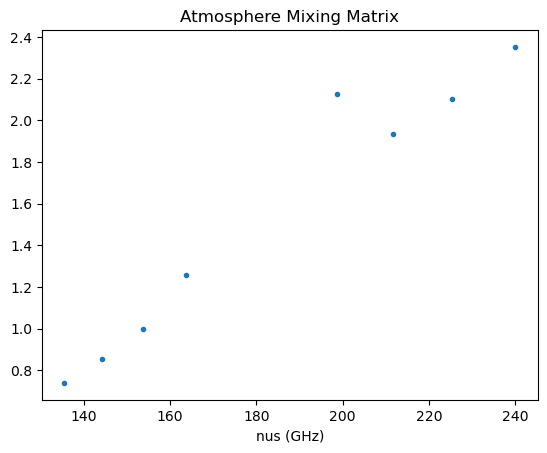

In [5]:
mixing_matrix = np.ones((params["nsub_in"], 2))
# Atm mixing matrix: normalized to reference frequency 150 GHz
mixing_matrix[:, 1] = atm.get_atm_mixing_matrix()
print(mixing_matrix.shape)

plt.plot(atm.frequencies, mixing_matrix[:, 1], ".")
plt.xlabel("nus (GHz)")
plt.title("Atmosphere Mixing Matrix")
plt.show()

# Scanning Strategy

In [6]:
### Random pointing
qubic_dict["random_pointing"] = True
qubic_dict["date_obs"] = "2023-10-01 22:57:00.000"
qubic_dict["fix_azimuth"]["apply"] = False

### Sweeping pointing
if params["sweeping_pointings"]:
    qubic_dict["random_pointing"] = False
    qubic_dict["sweeping_pointing"] = True

    qubic_dict["angspeed"] = 0.51
    qubic_dict["delta_az"] = 20
    qubic_dict["nsweeps_per_elevation"] = 15
    qubic_dict["duration"] = 0.1
    # npointings = 3600 * qubic_dict['duration'] / qubic_dict['period']
    qubic_dict["period"] = 3600 * qubic_dict["duration"] / params["npointings"]

### Repeat pointing
# qubic_dict["repeat_pointing"] = False

### Build scanning strategy instance
q_sampling_gal = get_pointing(qubic_dict)
qubic_patch = np.array([0, -57])
center_gal = equ2gal(qubic_patch[0], qubic_patch[1])
center_local = np.array([np.mean(q_sampling_gal.azimuth), np.mean(q_sampling_gal.elevation)])

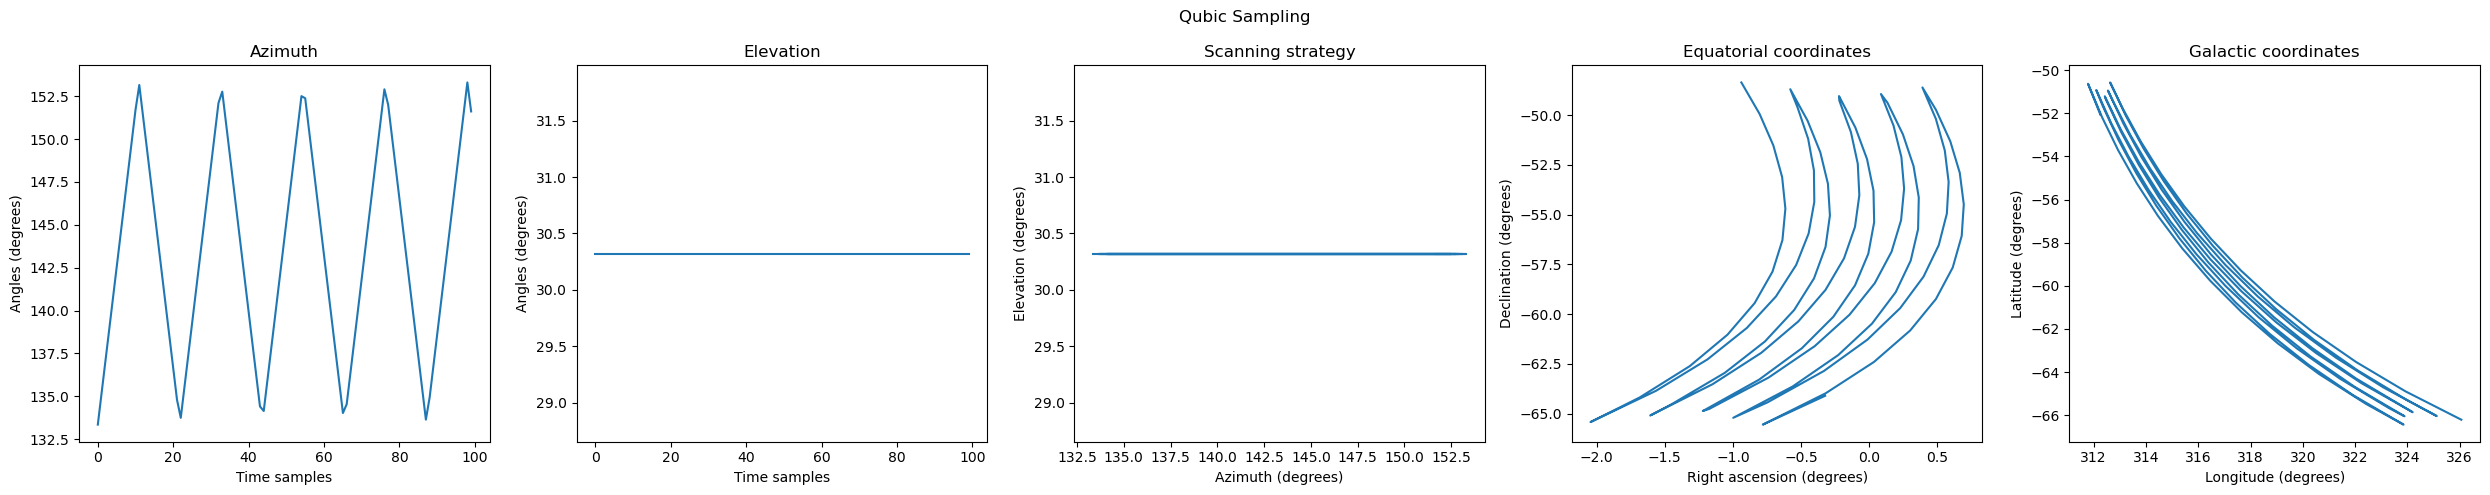

In [7]:
### Plot scanning strategy
az, el = q_sampling_gal.azimuth, q_sampling_gal.elevation

fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# Azimuth plot
axs[0].plot(az)
axs[0].set_title("Azimuth")
axs[0].set_xlabel("Time samples")
axs[0].set_ylabel("Angles (degrees)")

# Elevation plot
axs[1].plot(el)
axs[1].set_title("Elevation")
axs[1].set_xlabel("Time samples")
axs[1].set_ylabel("Angles (degrees)")

# Scanning strategy plot
axs[2].plot(az, el)
axs[2].set_title("Scanning strategy")
axs[2].set_xlabel("Azimuth (degrees)")
axs[2].set_ylabel("Elevation (degrees)")

# Equatorial coordinates plot
axs[3].plot((q_sampling_gal.equatorial[:, 0] + 180) % 360 - 180, q_sampling_gal.equatorial[:, 1])
axs[3].set_title("Equatorial coordinates")
axs[3].set_xlabel("Right ascension (degrees)")
axs[3].set_ylabel("Declination (degrees)")

# Galactic coordinates plot
axs[4].plot(q_sampling_gal.galactic[:, 0], q_sampling_gal.galactic[:, 1])
axs[4].set_title("Galactic coordinates")
axs[4].set_xlabel("Longitude (degrees)")
axs[4].set_ylabel("Latitude (degrees)")

fig.suptitle("Qubic Sampling")
plt.tight_layout()
plt.show()

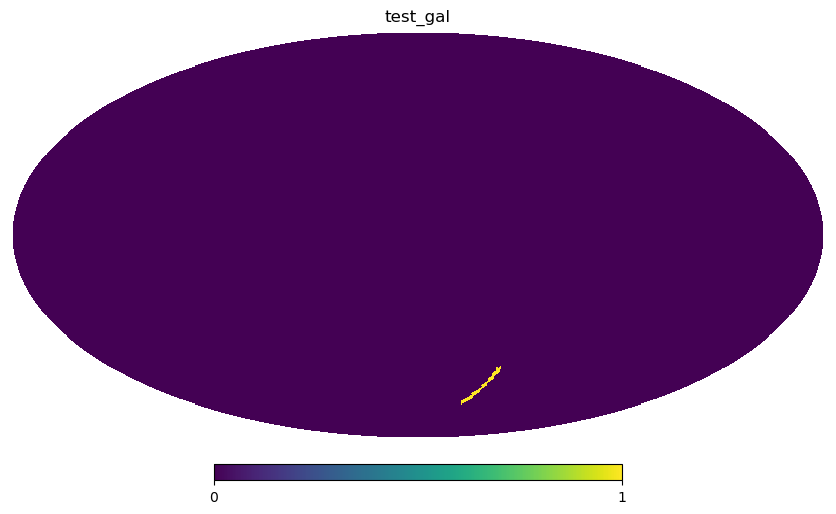

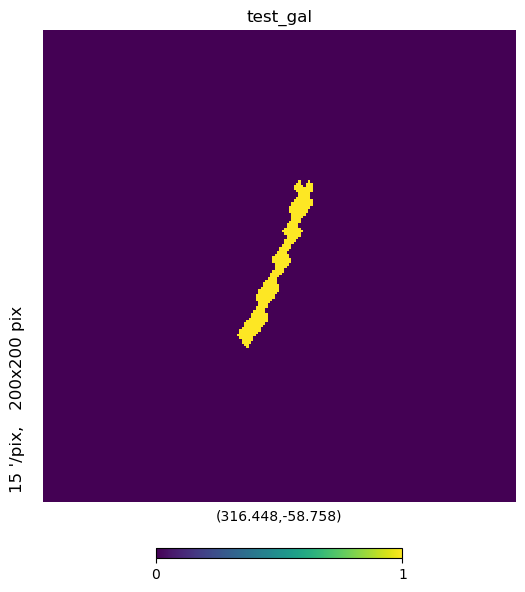

In [8]:
### Test scanning strategy plots
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians(q_sampling_gal.galactic)
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_gal", cmap="viridis")
hp.gnomview(test_gal, title="test_gal", cmap="viridis", reso=15, rot=center_gal)

## Build local sampling

In [9]:
### Define scanning strategy for atm observation
q_sampling_local_rec = QubicSampling(
    q_sampling_gal.index.size,
    date_obs=qubic_dict["date_obs"],
    period=qubic_dict["period"],
    latitude=qubic_dict["latitude"],
    longitude=qubic_dict["longitude"],
)

q_sampling_local_rec.azimuth = q_sampling_gal.azimuth
q_sampling_local_rec.elevation = q_sampling_gal.elevation
q_sampling_local_rec.pitch = q_sampling_gal.pitch
q_sampling_local_rec.angle_hwp = q_sampling_gal.angle_hwp

q_sampling_local_rec.fix_az = True

if params["wind"]:
    wind_class = WindPerturbation(params, q_sampling_gal)
    q_sampling_local = wind_class.get_deviated_qubic_sampling()
else:
    q_sampling_local = q_sampling_local_rec

## Build 1 pointing sampling list

In [10]:
print(q_sampling_local)

QubicSampling((100,), 
    index=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 2,
    angle_hwp=[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ,
    azimuth=[133.34925326 135.18542691 137.02160267 138.85778054 140.69396052,
    elevation=[30.32202693 30.32202693 30.32202693 30.32202693 30.32202693 30.3,
    equatorial=[[104.48751717 -48.3619657 ]
 [104.62155639 -49.94502489]
 [104.7,
    galactic=[[258.34270163 -18.90395121]
 [259.95168525 -19.35447335]
 [261.5,
    masked=False,
    pitch=[-10.    -9.64  -9.28  -8.92  -8.56  -8.2   -7.84  -7.48  -7.12  ,
    time=[  0.    3.6   7.2  10.8  14.4  18.   21.6  25.2  28.8  32.4  36.)


In [11]:
q_sampling = []

N_buffer = params["n_buffer"]

for ipointing in range(int(params["npointings"] / N_buffer)):
    tmp = QubicSampling(N_buffer)
    tmp.azimuth = q_sampling_gal.azimuth[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.elevation = q_sampling_gal.elevation[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.pitch = q_sampling_gal.pitch[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.angle_hwp = q_sampling_gal.angle_hwp[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.fix_az = True
    q_sampling.append(tmp)

# Atm

(8, 49152, 3)


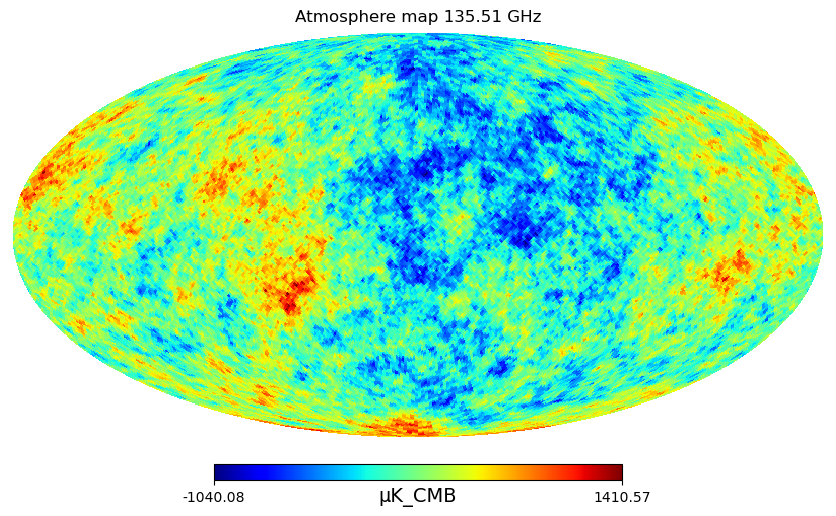

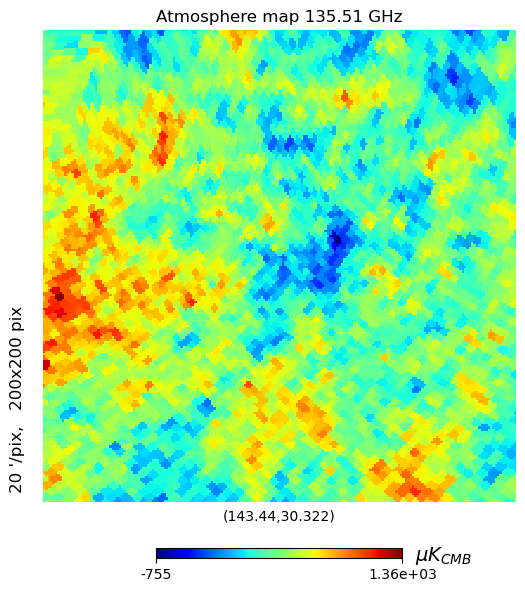

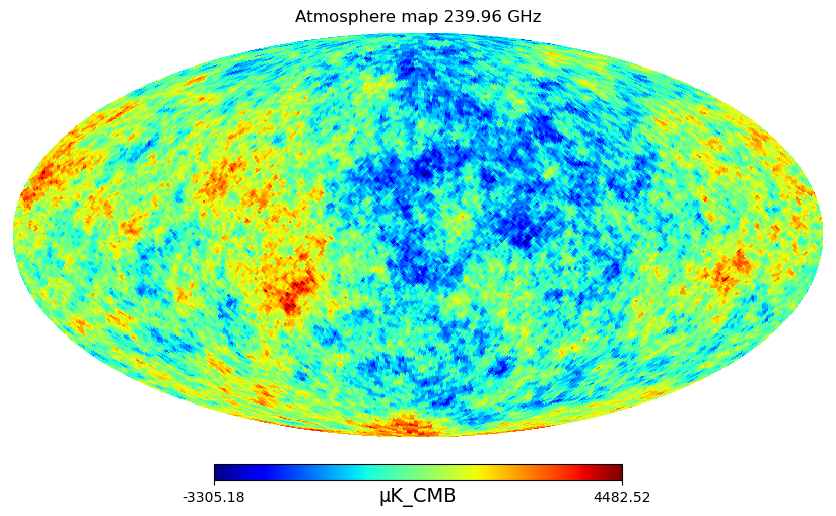

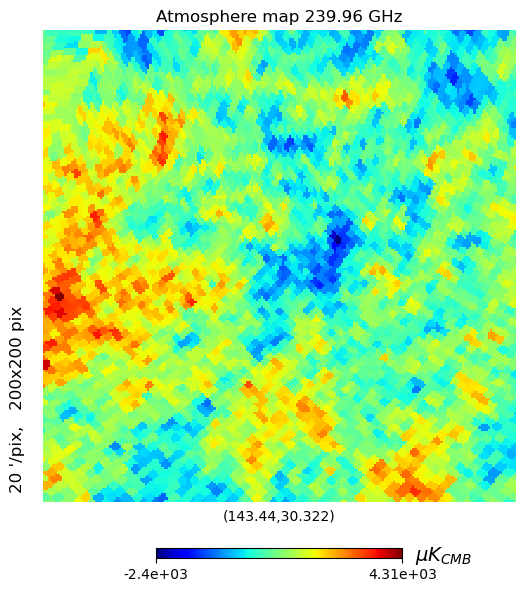

In [12]:
atm_maps = np.ones((params["nsub_in"], hp.nside2npix(params["nside"]), 3)) * atm.get_temp_maps(atm.delta_rho_map)[..., None] / 1e3
# true_maps = atm_maps.mean(axis=0)[None]
atm_maps[..., 1:] *= 0
print(atm_maps.shape)

index_nu = 0
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

index_nu = -1
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

# Wind Operator

In [13]:
@flags.linear
@flags.square
class ShiftOperator(Operator):
    """
    PyOperator wrapping rotate_healpy_map_by_wind.
    Applies a sky rotation defined by a 2D wind vector (wx, wy).
    """

    def __init__(self, wind, dtype=None, **keywords):
        # Always call parent __init__ first in PyOperators subclasses
        Operator.__init__(self, dtype=dtype, **keywords)
        self.wind = np.asarray(wind, dtype=float)  # (wx, wy)

    def direct(self, input_map, out):
        wind_x, wind_y = self.wind
        m_rot = wind_class.shift_healpy_map(input_map, wind_x, wind_y, verbose=False)
        out[...] = m_rot

    def transpose(self, input_map, out):
        wind_x, wind_y = self.wind
        m_rot = wind_class.shift_healpy_map(input_map, -wind_x, -wind_y, verbose=False)
        out[...] = m_rot


def get_wind_operator(
    wind,
    Npointings=params["npointings"],
    Nsub=params["nsub_rec"],
    N_buffer=N_buffer,
    nside=params["nside"],
):
    npix = hp.nside2npix(nside)
    shape = (Nsub, npix, 3)
    wind_x, wind_y = wind

    # Convert scalar wind speed to cumulative displacement, matching get_constant_wind
    if np.isscalar(wind_x):
        wind_x = wind_x * np.cumsum(np.ones(Npointings, dtype=float))
    if np.isscalar(wind_y):
        wind_y = wind_y * np.cumsum(np.ones(Npointings, dtype=float))

    chunks = range(0, Npointings, N_buffer)

    tmp = []
    for i in chunks:
        wx_chunk = float(np.mean(wind_x[i : i + N_buffer]))
        wy_chunk = float(np.mean(wind_y[i : i + N_buffer]))

        tmp.append(
            ShiftOperator(
                wind=(wx_chunk, wy_chunk),
                shapein=shape,
                shapeout=shape,
            )
        )

    return BlockColumnOperator(tmp, axisout=0)


# Expected output shape: (n_chunks * nsub_rec, npix, 3)
n_chunks = len(range(0, params["npointings"], N_buffer))
print("Expected output shape:", (n_chunks * params["nsub_rec"], npix, 3))

shift_test = get_wind_operator(wind_class.get_wind(), Npointings=params["npointings"], Nsub=1)

print("shift:", shift_test.shapein, "→", shift_test.shapeout)

Expected output shape: (40, 49152, 3)
shift: (1, 49152, 3) → (5, 49152, 3)


In [14]:
@flags.linear
class PermuteChunksOperator(Operator):
    """
    Reorder TOD from BlockDiagonalOperator's (n_chunks, D, N_buffer) layout
    to the full-acquisition (D, n_chunks, N_buffer) = (D, Npointings) layout.

    BlockDiagonalOperator concatenates per-chunk outputs naively, so chunk 0's
    detectors come before chunk 1's detectors.  The full H_tod operator instead
    produces all time samples for each detector consecutively.  This operator
    corrects that axis swap.

    Direct:    chunked ordering → full ordering   (axes 0↔1 of the 3-D view)
    Transpose: full ordering    → chunked ordering
    """

    def __init__(self, n_chunks, D, N_buffer, **keywords):
        self.n_chunks = n_chunks
        self.D = D
        self.N_buffer = N_buffer
        N = n_chunks * D * N_buffer
        Operator.__init__(self, shapein=(N,), shapeout=(N,), **keywords)

    def direct(self, input, out):
        nc, D, Nb = self.n_chunks, self.D, self.N_buffer
        out[...] = input.reshape(nc, D, Nb).transpose(1, 0, 2).ravel()

    def transpose(self, input, out):
        nc, D, Nb = self.n_chunks, self.D, self.N_buffer
        out[...] = input.reshape(D, nc, Nb).transpose(1, 0, 2).ravel()


In [15]:
def create_mollview_gif(maps, duration=100):
    """
    Create a GIF from a sequence of HEALPix maps and display it inline (no file saved).

    Parameters:
    -----------
    maps : list of np.ndarray
        List of HEALPix maps to animate.
    duration : int
        Time between frames in milliseconds.

    Returns:
    --------
    IPython.display.Image object (displays automatically in notebook)
    """
    frames = []
    range = np.max([-np.min(maps[0]), np.max(maps[0])])

    for i, m in enumerate(maps):
        fig = plt.figure(figsize=(10, 6))
        hp.mollview(m, fig=fig, title=f"Frame {i + 1}", unit="K", cmap="jet", min=-range, max=range)

        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=100, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf))
        plt.close(fig)

    # Save to an in-memory bytes buffer
    gif_buffer = io.BytesIO()
    frames[0].save(
        gif_buffer,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0,
        optimize=True,
        format="GIF",
    )
    gif_buffer.seek(0)

    # Return an IPython Image object (will be displayed automatically)
    return IPyImage(data=gif_buffer.getvalue())

def create_gnomview_gif(maps, rot, reso=20, duration=100, title = None):
    frames = []
    range = np.max([-np.min(maps[0]), np.max(maps[0])])
    
    if title is None:
        title = "Frame "

    for i, m in enumerate(maps):
        fig = plt.figure(figsize=(10, 6))
        hp.gnomview(
            m,
            fig=fig,
            title=f"{title} {i + 1}",
            unit="K",
            cmap="jet",
            min=-range,
            max=range,
            rot=rot,
            reso=reso,
        )

        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=100, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf))
        plt.close(fig)

    # Save to an in-memory bytes buffer
    gif_buffer = io.BytesIO()
    frames[0].save(
        gif_buffer,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0,
        optimize=True,
        format="GIF",
    )
    gif_buffer.seek(0)

    # Return an IPython Image object (will be displayed automatically)
    return IPyImage(data=gif_buffer.getvalue())

# test = shift_test(true_maps)
# print(test.shape)

# create_mollview_gif(test[..., 0])

# True maps

(5, 49152, 3)


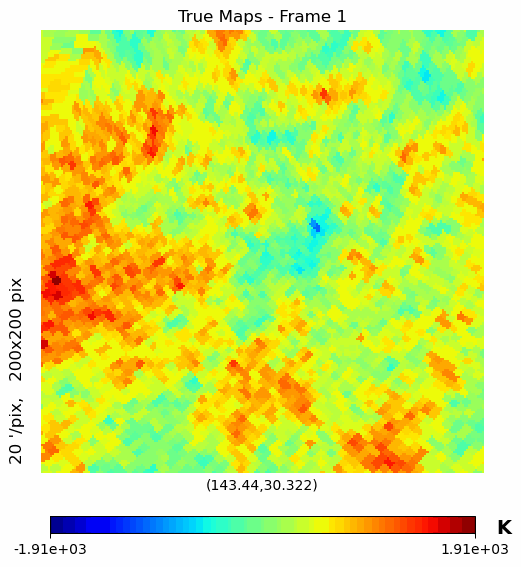

In [16]:
true_maps = np.ones((1, hp.nside2npix(params["nside"]), 3)) * atm.get_ref_temp_maps(atm.delta_rho_map)[..., None] / 1e3

wind = get_wind_operator(wind_class.get_wind(), Npointings=params["npointings"], Nsub=1, N_buffer=N_buffer)

true_maps_shifted = wind(true_maps)
print(true_maps_shifted.shape)

create_gnomview_gif(true_maps_shifted[..., 0], rot=center_local, reso=20, duration=500, title = "True Maps - Frame")

In [17]:
print(true_maps_shifted.shape)

min_input = np.min(true_maps_shifted, axis=1)
max_input = np.max(true_maps_shifted, axis=1)

max = np.max([min_input, max_input], axis=0)
min_input = -max
max_input = max

(5, 49152, 3)


# Map-making

## Tod acquisition

Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.72

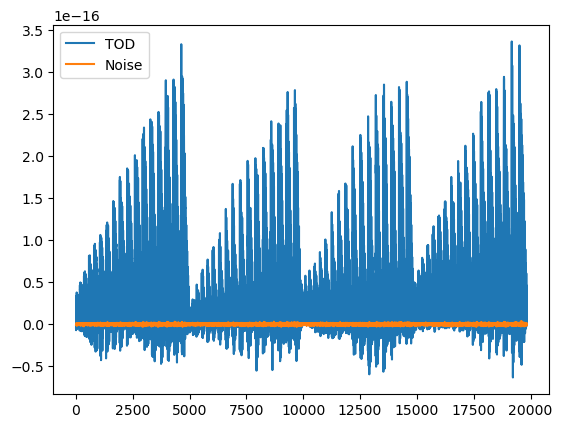

In [18]:
# Build the QUBIC operators with deviated pointing
# H_tod = QubicInstrumentType(
#     atm.qubic_dict, nsub=params["nsub_in"], nrec=params["nsub_in"], sampling=q_sampling_local
# ).get_operator()

# Build the QUBIC operators with shifting operator
h_tod = []
for ipointing in range(int(params["npointings"] / N_buffer)):
    acq = QubicInstrumentType(
        atm.qubic_dict, nsub=params["nsub_in"], nrec=params["nsub_in"], sampling=q_sampling[ipointing]
    )
    h_tod.append(acq.get_operator())
    # acq.free_comms()

# D = nsub * Ndet (number of "virtual detectors" per time sample)
n_chunks = params["npointings"] // N_buffer
ndet = 992

Pchunk = PermuteChunksOperator(1, ndet, N_buffer)
print("Pchunk :", Pchunk.shapein, Pchunk.shapeout)

qubic_scene = QubicScene(qubic_dict)

wind_op = get_wind_operator(wind_class.get_wind(), Npointings=params["npointings"], Nsub=params["nsub_in"], N_buffer=N_buffer)
print("wind_op:", wind_op.shapein, wind_op.shapeout)

atm_maps_shifted = wind_op(atm_maps)
print("atm_maps_shifted:", atm_maps_shifted.shape)
print(h_tod[0].shapein, h_tod[0].shapeout)

tod = []
for i in range(n_chunks):
    qubic_noise = QubicTotNoise(qubic_dict, q_sampling[i], qubic_scene).total_noise(params["wdet"], params["wpho150"], params["wpho220"], seed_noise=params["seed"]).ravel()
    tod.append((Pchunk * h_tod[i](atm_maps_shifted[i * params["nsub_in"] : (i + 1) * params["nsub_in"]])).ravel() + qubic_noise)
tod = np.array(tod)
print(tod.shape)

plt.plot(tod[0], label="TOD")
plt.plot(qubic_noise, label="Noise")
plt.legend()
plt.show()

del h_tod

## Rec acquisition

In [19]:

# 1 pointing acq
H_rec = []
invN_rec = []
seenpix_rec = []

for ipointing in range(int(params["npointings"] / N_buffer)):
    tmp = QubicInstrumentType(
        qubic_dict, params["nsub_rec"], params["nsub_rec"], sampling=q_sampling[ipointing]
    )
    H_rec.append(tmp.get_operator())
    invN_rec.append(tmp.get_invntt_operator(params["wdet"], params["wpho150"], params["wpho220"]))
    coverage = tmp.coverage
    covnorm = coverage / coverage.max()
    seenpix = covnorm > params["coverage_cut"]
    seenpix_rec.append(seenpix)
    # tmp.free_comms()
seenpix_rec = np.array(seenpix_rec)
print("seenpix_rec:", np.shape(seenpix_rec))

Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.724609375 MiB in FSRRotation3dMatrix.__init__.
Info arch-pc: Allocating (19840,9) elements = 2.72

# Rec Operator

In [20]:
Amm = DenseOperator(
    mixing_matrix[:, 1, None],
    broadcast="rightward",
    shapein=(1, npix, 3),
    shapeout=(params["nsub_in"], npix, 3),
)
print("A :", Amm.shapein, Amm.shapeout)

A : (1, 49152, 3) (8, 49152, 3)


In [21]:
def call_pcg(A, b, x0, max_iter=5, M=None, seenpix=None):
    algo = PCGAlgorithm(
        A,
        b,
        comm,
        x0=x0,
        tol=1e-12,
        maxiter=max_iter,
        disp=True,
        M=M,
        center=[0, -57],
        reso=15,
        seenpix=seenpix,
        input=true_maps,
    )
    try:
        result = algo.run()
        success = True
        message = "Success"
    except AbnormalStopIteration as e:
        result = algo.finalize()
        success = False
        message = str(e)

    return result

# Run Map-Making

In [22]:
# Fix CMB Intensity + Atm Polarisation
mask = np.ones(true_maps.shape)  # Mask for 2 components : CMB & Atm
print(mask.shape)
if params["cmb"] and not params["atm"]:
    mask[..., 0] = 0  # CMB Intensity
elif params["cmb"] and params["atm"]:
    mask[0, :, 0] = 0
    mask[1, :, [1, 2]] = 0  # Atm Polarisation
elif not params["cmb"] and params["atm"]:
    mask[..., [1, 2]] = 0
if params["fix_maps"]:
    P = PackOperator(mask).T  # Build Mask Operator
else:
    P = IdentityOperator()
x_masked = true_maps * (1 - mask)
print("P : ", P.shapein, P.shapeout)

# Start from uniform mixing-matrix (= 1)
mixing_matrix_rec = np.ones_like(mixing_matrix)

# Preconditioner
M = None

(1, 49152, 3)
P :  (49152,) (1, 49152, 3)


In [23]:
# Run PCG
convergence = np.empty((params["n_loop"], n_chunks, params["n_iter"]))
maps_rec = np.zeros((n_chunks, npix))
print(maps_rec.shape)

R = ReshapeOperator((ndet, N_buffer), (N_buffer * ndet))
print("R : ", R.shapein, R.shapeout)

Pchunk = PermuteChunksOperator(1, ndet, N_buffer)
print("Pchunk :", Pchunk.shapein, Pchunk.shapeout)

for iloop in range(params["n_loop"]):
    for ichunk in range(n_chunks):
        print("=====================================")
        print("Iteration : ", iloop)

        print("-------------------------------------")
        print("Fit Maps :")
        print("-------------------------------------")
        H = Pchunk * H_rec[ichunk]  * Amm
        invN = R * invN_rec[ichunk] * R.T
        
        A = P.T * H.T * invN * H * P
        b = P.T * H.T * invN * (tod[ichunk] - H(x_masked))
        
        if iloop == 0 and ichunk == 0:
            x0 = maps_rec[ichunk].copy()
        elif ichunk == 0:
            x0 = maps_rec[-1].copy()
        else:
            x0 = maps_rec[ichunk].copy()

        if params["iterative_iter"]:
            n_iter = iloop
        else:
            n_iter = params["n_iter"]

        result = call_pcg(A, b, x0, max_iter=n_iter, M=M, seenpix=seenpix_rec[ichunk])
        convergence[iloop, ichunk] = result["convergence"]
        output = result["x"].copy()
        print("Previous Maps: ", maps_rec[ichunk].mean(axis=0))
        maps_rec[ichunk] = output

        print("Next Maps: ", maps_rec[ichunk].mean(axis=0))
        print("Residual Maps: ", (P.T(true_maps)  - maps_rec[ichunk])[seenpix_rec[ichunk]].mean(axis=0))
        
print("=====================================")
print("End of the loop !")    
print("=====================================")

for ichunk in range(n_chunks):
        print("=====================================")
        print("Iteration : ", iloop)

        print("-------------------------------------")
        print("Fit Maps :")
        print("-------------------------------------")
        H = Pchunk * H_rec[ichunk]  * Amm
        invN = R * invN_rec[ichunk] * R.T
        
        A = P.T * H.T * invN * H * P
        b = P.T * H.T * invN * (tod[ichunk] - H(x_masked))
        
        if iloop == 0 and ichunk == 0:
            x0 = maps_rec[ichunk].copy()
        elif ichunk == 0:
            x0 = maps_rec[-1].copy()
        else:
            x0 = maps_rec[ichunk - 1].copy()

        if params["iterative_iter"]:
            n_iter = iloop
        else:
            n_iter = params["n_iter"]

        result = call_pcg(A, b, x0, max_iter=250, M=M, seenpix=seenpix_rec[ichunk])
        convergence_last = result["convergence"]
        output = result["x"].copy()
        print("Previous Maps: ", maps_rec[ichunk].mean(axis=0))
        maps_rec[ichunk] = output

        print("Next Maps: ", maps_rec[ichunk].mean(axis=0))
        print("Residual Maps: ", (P.T(true_maps)  - maps_rec[ichunk])[seenpix_rec[ichunk]].mean(axis=0))

(5, 49152)
R :  (992, 20) (19840,)
Pchunk : (19840,) (19840,)
Iteration :  0
-------------------------------------
Fit Maps :
-------------------------------------
 Iter     Tol      time
   1: 4.2630e-01 0.02343 [0. 0. 0.]
   2: 1.1053e-01 0.01926 [0. 0. 0.]
   3: 1.0274e-01 0.01772 [0. 0. 0.]
   4: 4.1397e-02 0.01989 [0. 0. 0.]
   5: 3.5590e-02 0.02232 [0. 0. 0.]
   6: 3.4421e-02 0.02124 [0. 0. 0.]
   7: 3.6108e-02 0.01856 [0. 0. 0.]
   8: 2.3379e-02 0.01783 [0. 0. 0.]
   9: 2.4147e-02 0.01750 [0. 0. 0.]
  10: 2.6059e-02 0.01866 [0. 0. 0.]
  11: 2.0614e-02 0.01753 [0. 0. 0.]
  12: 1.4846e-02 0.01784 [0. 0. 0.]
  13: 1.6869e-02 0.01734 [0. 0. 0.]
  14: 1.4678e-02 0.01861 [0. 0. 0.]
  15: 1.3617e-02 0.02002 [0. 0. 0.]
  16: 1.2740e-02 0.01800 [0. 0. 0.]
  17: 1.0570e-02 0.01739 [0. 0. 0.]
  18: 1.1325e-02 0.01817 [0. 0. 0.]
  19: 1.0271e-02 0.01773 [0. 0. 0.]
  20: 1.0616e-02 0.01758 [0. 0. 0.]
  21: 8.7065e-03 0.01751 [0. 0. 0.]
  22: 7.5320e-03 0.01795 [0. 0. 0.]
  23: 8.8545e-03 0.0

# Convergence & Plot

Text(0, 0.5, 'Convergence')

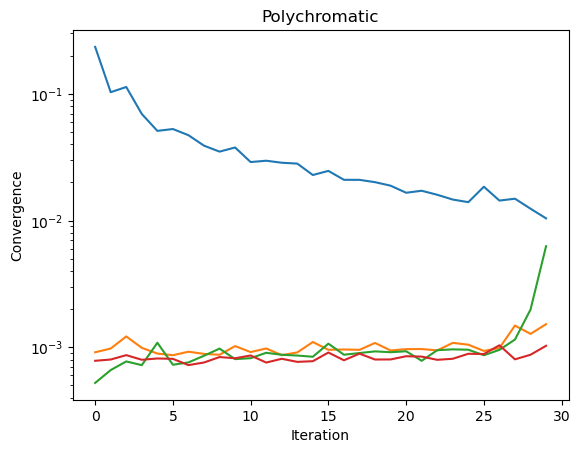

In [24]:
for conv in convergence[-1][:-1]:
    plt.plot(conv)
    
# plt.plot(convergence[-1], label="Final PCG convergence")
plt.title("Polychromatic")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Convergence")

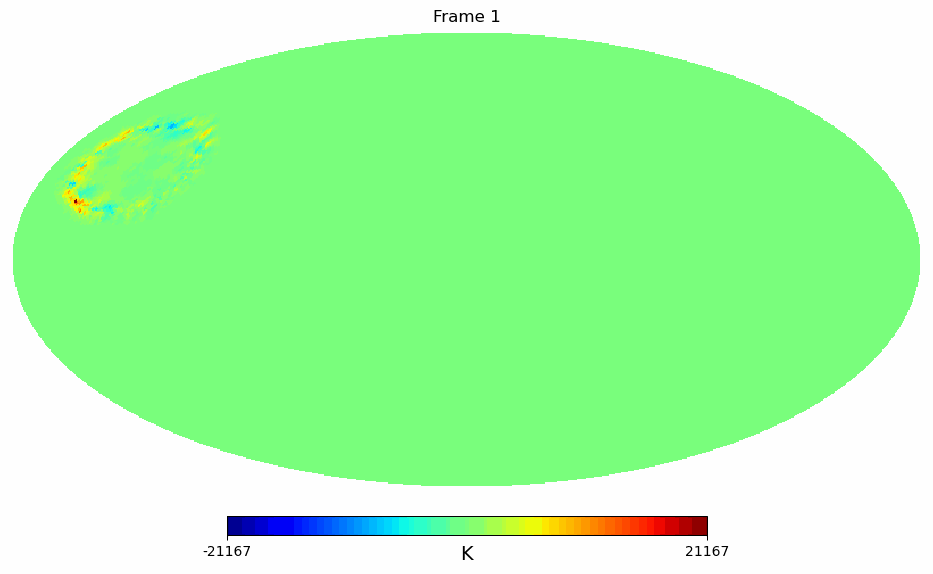

In [25]:
create_mollview_gif(maps_rec, duration=500)

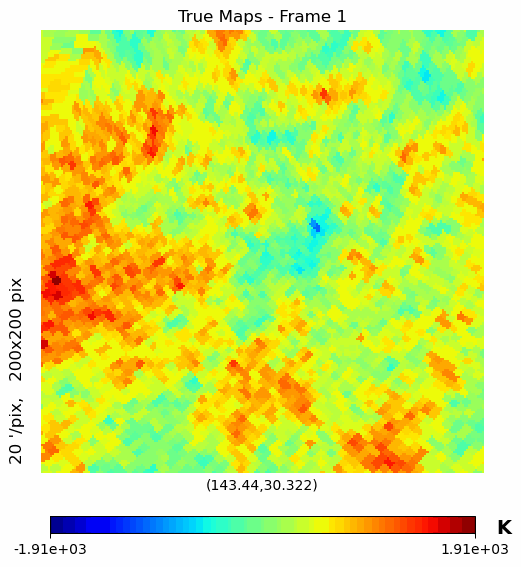

In [26]:
create_gnomview_gif(maps=true_maps_shifted[..., 0], rot=center_local, reso=20, duration=500, title = "True Maps - Frame")

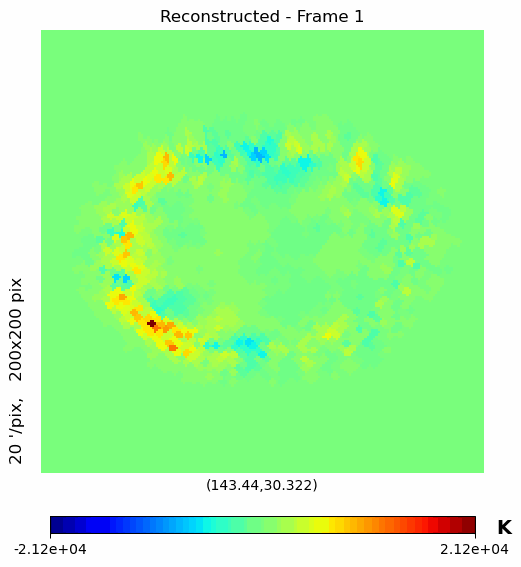

In [27]:
create_gnomview_gif(maps_rec, rot=center_local, reso=20, duration=500, title = "Reconstructed - Frame")

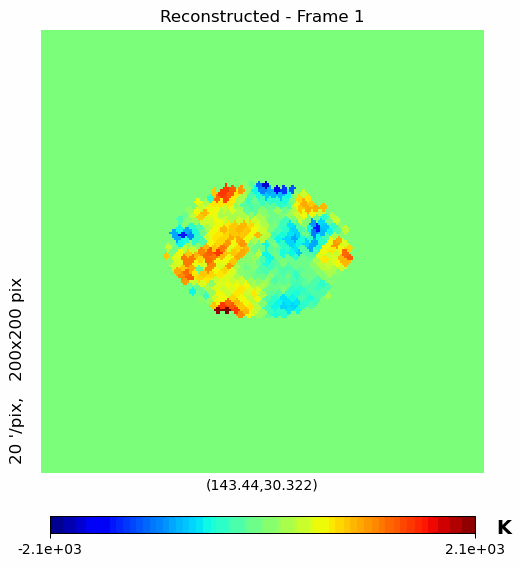

In [28]:
maps_rec_seenpix = maps_rec.copy()
for i in range(n_chunks):
    maps_rec_seenpix[i][~seenpix_rec[i]] = 0
create_gnomview_gif(maps_rec_seenpix, rot=center_local, reso=20, duration=500, title = "Reconstructed - Frame")

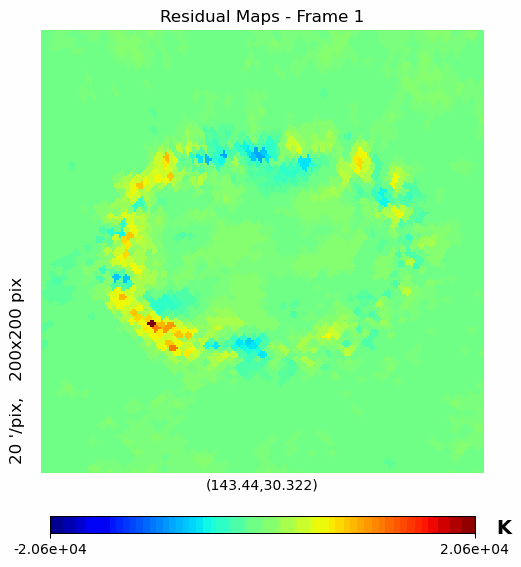

In [29]:
map_res = maps_rec - true_maps[..., 0]
create_gnomview_gif(map_res, rot=center_local, reso=20, duration=500, title = "Residual Maps - Frame")

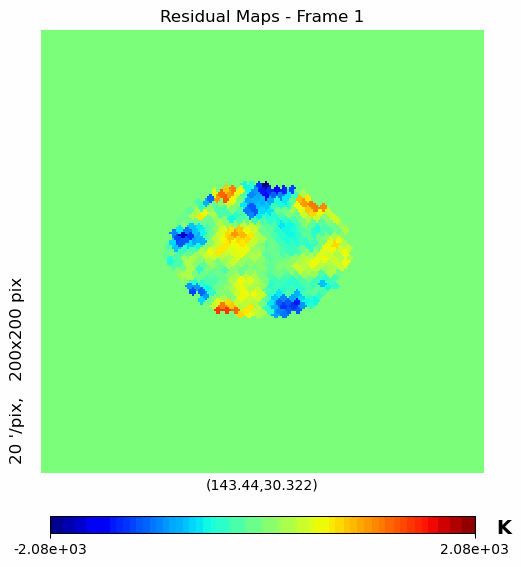

In [30]:
map_res_seenpix = map_res.copy()
map_res_seenpix[~seenpix_rec] = 0
create_gnomview_gif(map_res_seenpix, rot=center_local, reso=20, duration=500, title = "Residual Maps - Frame")